In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#  Pollution dataset
temp = np.random.uniform(20, 40, 100)
traffic = np.random.randint(50, 200, 100)

pollution = 0.5*temp + 0.3*traffic + np.random.randn(100)*5

df = pd.DataFrame({
    "temperature": temp,
    "traffic": traffic,
    "pollution": pollution
})

In [5]:
df.head()

,temperature,traffic,pollution
0,26.160369,74,36.521470
1,23.124973,103,43.637283
2,23.419547,176,64.019550
3,35.350361,119,49.878039
4,21.628604,174,52.642475


In [6]:
df.shape

(100, 3)

In [7]:
df.sum().isnull()

temperature    False
traffic        False
pollution      False
dtype: bool

In [8]:
X = df[["temperature", "traffic"]]
y = df["pollution"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [12]:
y_pred = knn.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 24.821339663550493
R2 Score: 0.7254264081829317


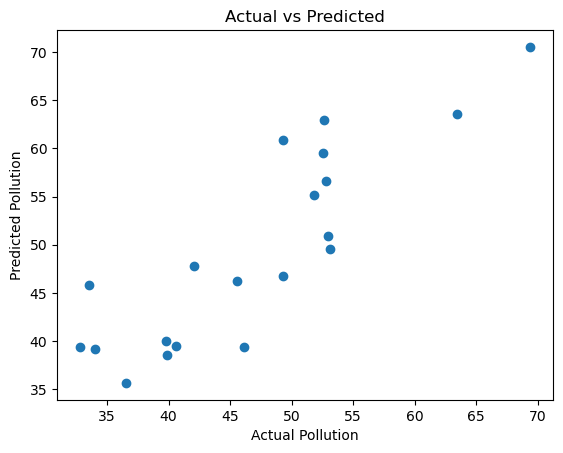

In [17]:

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Actual vs Predicted")
plt.show()

### Try different K values:

In [15]:
for k in range(1, 11):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(k, r2_score(y_test, y_pred))

1 0.37961485441050624
2 0.6013209232596556
3 0.696436195681182
4 0.7322107690664919
5 0.7254264081829317
6 0.7378236788324573
7 0.668986411317229
8 0.6347091271524654
9 0.6696937415231414
10 0.6416813584303884
